In [2]:
from scipy.stats import poisson, binom, expon
import matplotlib.pyplot as plt
import math
import numpy as np

La funzione da studiare è:
n_sigma = S / sqrt(S + B)

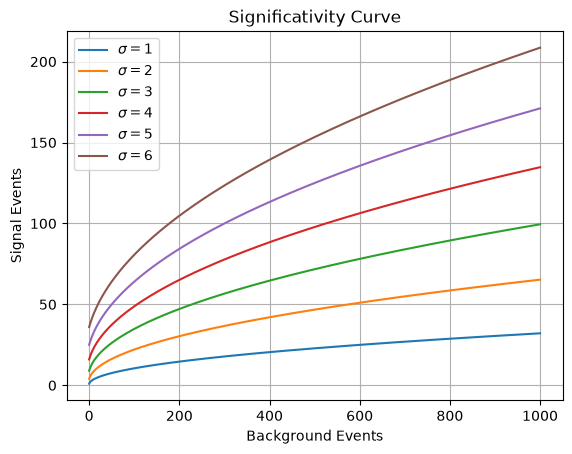

In [7]:
sigma = [1, 2, 3, 4, 5, 6]   # lista delle significatività di interesse
B = np.arange(0,1001) # eventi di Background
sqB = np.sqrt(B)

fig, ax = plt.subplots()

for n in sigma:
    #S = n * sqB
    S = n / 2 * (n + np.sqrt(n**2 + 4*B))
    ax.plot(B, S, label=rf"$\sigma = {n:.0f}$")

ax.set_xlabel("Background Events")
ax.set_ylabel("Signal Events")
ax.set_title("Significativity Curve")
ax.grid(True)
ax.legend()
plt.show()

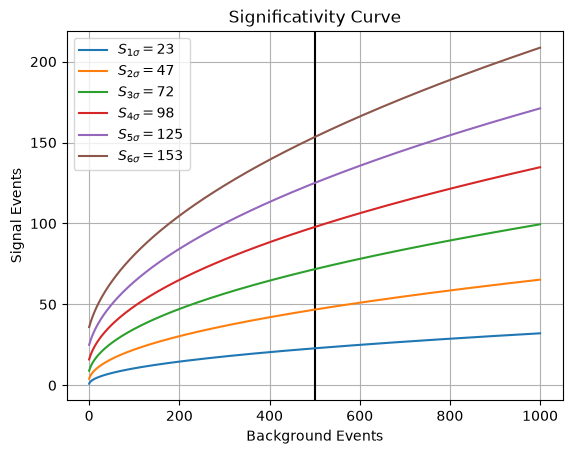

In [17]:
bk_fixed = 500

if bk_fixed < 0:
    print("ERRORE: inserire solo valori positivi per indicare il numero di eventi di background.")
else:
    sq_bkfix = np.sqrt(bk_fixed)
    fig, ax = plt.subplots()
    ax.axvline(bk_fixed, color="black")
    for n in sigma:
        #S = n * sqB
        S = n / 2 * (n + np.sqrt(n**2 + 4*B))
        S_intersect = n / 2 * (n + np.sqrt(n**2 + 4*bk_fixed))
        ax.plot(B, S, label=fr"$S_{{{n}\sigma}} = {S_intersect:.0f}$")
    
    ax.set_xlabel("Background Events")
    ax.set_ylabel("Signal Events")
    ax.set_title("Significativity Curve")
    ax.grid(True)
    ax.legend()
    plt.show()

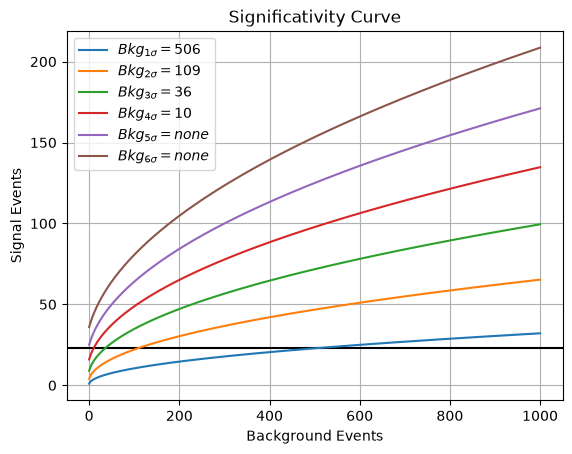

In [20]:
s_fixed = 23


if s_fixed < 0:
    print("ERRORE: inserire solo valori positivi per indicare il numero di eventi di segnale.")
else:
    
    fig, ax = plt.subplots()
    ax.axhline(s_fixed, color="black")
    
    for n in sigma:
        S = n / 2 * (n + np.sqrt(n**2 + 4*B))
        B_intersect = s_fixed * (s_fixed/n**2 - 1)
        if B_intersect <= 0:
            ax.plot(B, S, label=fr"$Bkg_{{{n}\sigma}} = none$")
        else:
            ax.plot(B, S, label=fr"$Bkg_{{{n}\sigma}} = {B_intersect:.0f}$")
    
    ax.set_xlabel("Background Events")
    ax.set_ylabel("Signal Events")
    ax.set_title("Significativity Curve")
    ax.grid(True)
    ax.legend()
    plt.show()